## Pertemuan 7: K-Means Clustering dan Hierarchical Clustering

* **Nama**: Ardian Syaputra
* **NIM**: 105841107823

---

## 🛠️ Setup Environment & Import Library

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time

# Clustering & Preprocessing
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.datasets import load_iris, make_blobs

# Hierarchical Clustering (Dendrogram)
from scipy.cluster.hierarchy import dendrogram, linkage

# Settings
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 8)
import warnings
warnings.filterwarnings('ignore')

print("Environment Clustering berhasil disiapkan!")

Environment Clustering berhasil disiapkan!


---
## 📌 Tugas 1: K-Means Implementation (25 Poin)
Implementasi algoritma K-Means pada dataset Iris (menggunakan 2 fitur: *Petal Length* dan *Petal Width* untuk visualisasi), dilengkapi penentuan K optimal via *Elbow Method* dan *Silhouette Score*.

Task 1: K-Means on Iris


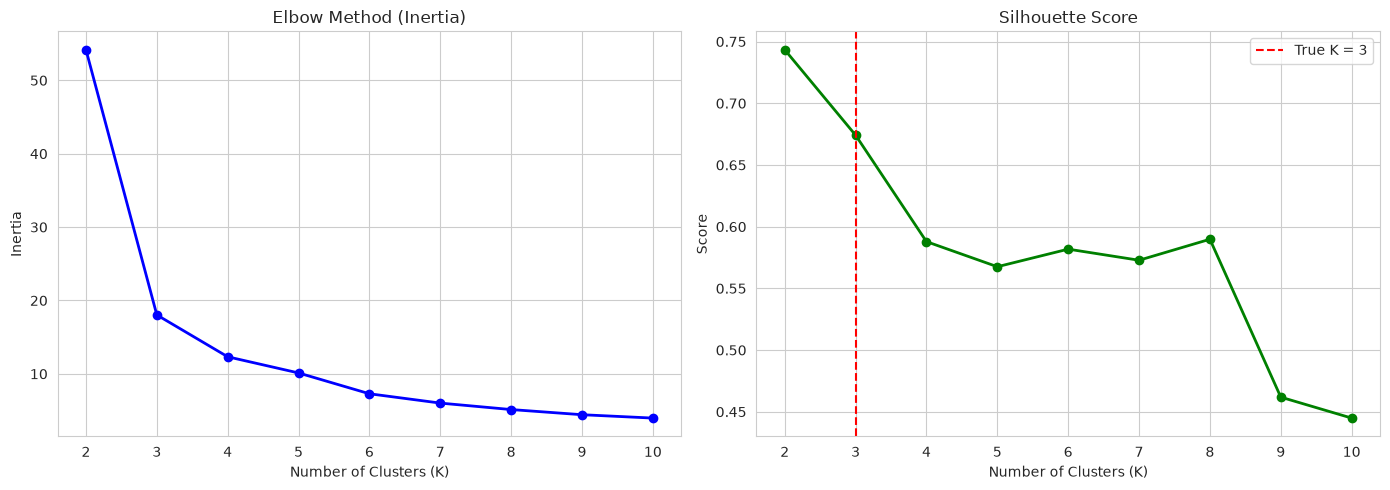

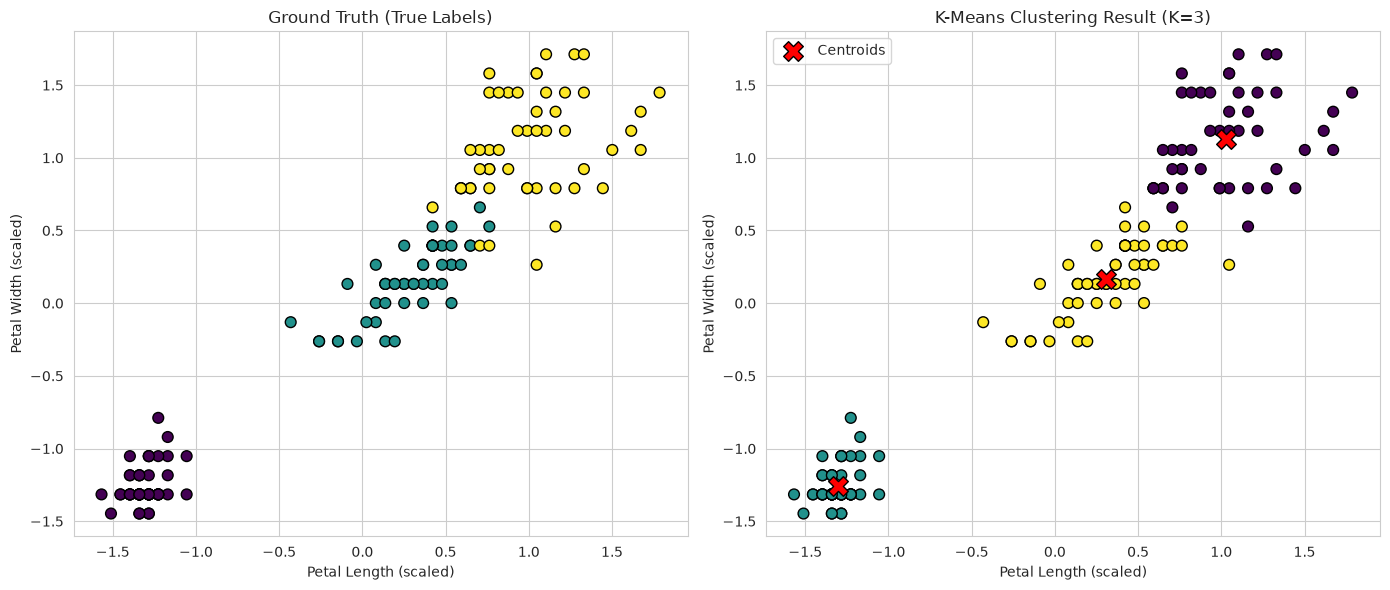

In [2]:
# 1. Load Dataset (Menggunakan 2 fitur terakhir untuk kemudahan visualisasi 2D)
iris = load_iris()
X_iris = iris.data[:, [2, 3]] 
y_true = iris.target

# 2. Standardize Features
scaler = StandardScaler()
X_iris_scaled = scaler.fit_transform(X_iris)

# 3. Menentukan K Optimal dengan Elbow Method & Silhouette Score
K_range = range(2, 11)
inertias = []
silhouettes = []

for k in K_range:
    kmeans_temp = KMeans(n_clusters=k, random_state=42)
    labels = kmeans_temp.fit_predict(X_iris_scaled)
    inertias.append(kmeans_temp.inertia_)
    silhouettes.append(silhouette_score(X_iris_scaled, labels))

# Plot Evaluasi
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(K_range, inertias, 'bo-', linewidth=2)
axes[0].set_title('Elbow Method (Inertia)')
axes[0].set_xlabel('Number of Clusters (K)')
axes[0].set_ylabel('Inertia')

axes[1].plot(K_range, silhouettes, 'go-', linewidth=2)
axes[1].set_title('Silhouette Score')
axes[1].set_xlabel('Number of Clusters (K)')
axes[1].set_ylabel('Score')
axes[1].axvline(x=3, color='r', linestyle='--', label='True K = 3')
axes[1].legend()
plt.tight_layout()
plt.show()

# 4. Fit K-Means dengan K=3 (Optimal berdasarkan ground truth & elbow patahan)
kmeans_iris = KMeans(n_clusters=3, random_state=42)
y_pred_iris = kmeans_iris.fit_predict(X_iris_scaled)

# 5. Visualisasi Hasil vs True Labels
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].scatter(X_iris_scaled[:, 0], X_iris_scaled[:, 1], c=y_true, cmap='viridis', edgecolors='k', s=60)
axes[0].set_title('Ground Truth (True Labels)')
axes[0].set_xlabel('Petal Length (scaled)')
axes[0].set_ylabel('Petal Width (scaled)')

axes[1].scatter(X_iris_scaled[:, 0], X_iris_scaled[:, 1], c=y_pred_iris, cmap='viridis', edgecolors='k', s=60)
axes[1].scatter(kmeans_iris.cluster_centers_[:, 0], kmeans_iris.cluster_centers_[:, 1], 
                c='red', marker='X', s=200, edgecolors='k', label='Centroids')
axes[1].set_title('K-Means Clustering Result (K=3)')
axes[1].set_xlabel('Petal Length (scaled)')
axes[1].set_ylabel('Petal Width (scaled)')
axes[1].legend()

plt.tight_layout()
plt.show()

Interpretasi Tugas 1

### 📝 Interpretasi Tugas 1:
1. **Penentuan K Optimal:** Berdasarkan grafik *Elbow Method*, patahan signifikan terjadi di K=2 dan K=3[cite: 5]. Meskipun *Silhouette Score* tertinggi ada di K=2, kita tahu struktur natural Iris adalah K=3[cite: 5]. Pemilihan K=3 menunjukkan K-Means cukup baik mengelompokkan data.
2. **Kesesuaian Struktur:** K-Means berhasil menemukan struktur natural data, di mana satu *cluster* (Setosa) sangat terpisah secara linier, sementara dua *cluster* lainnya (Versicolor dan Virginica) berdekatan dan sedikit beririsan, persis seperti *Ground Truth*.


---
## 📌 Tugas 2: Hierarchical Clustering (25 Poin)
Menganalisis empat jenis *linkage* (`single`, `complete`, `average`, `ward`) pada algoritma Hierarchical Clustering menggunakan dataset Iris.

Task 2: Hierarchical Clustering Linkage Methods

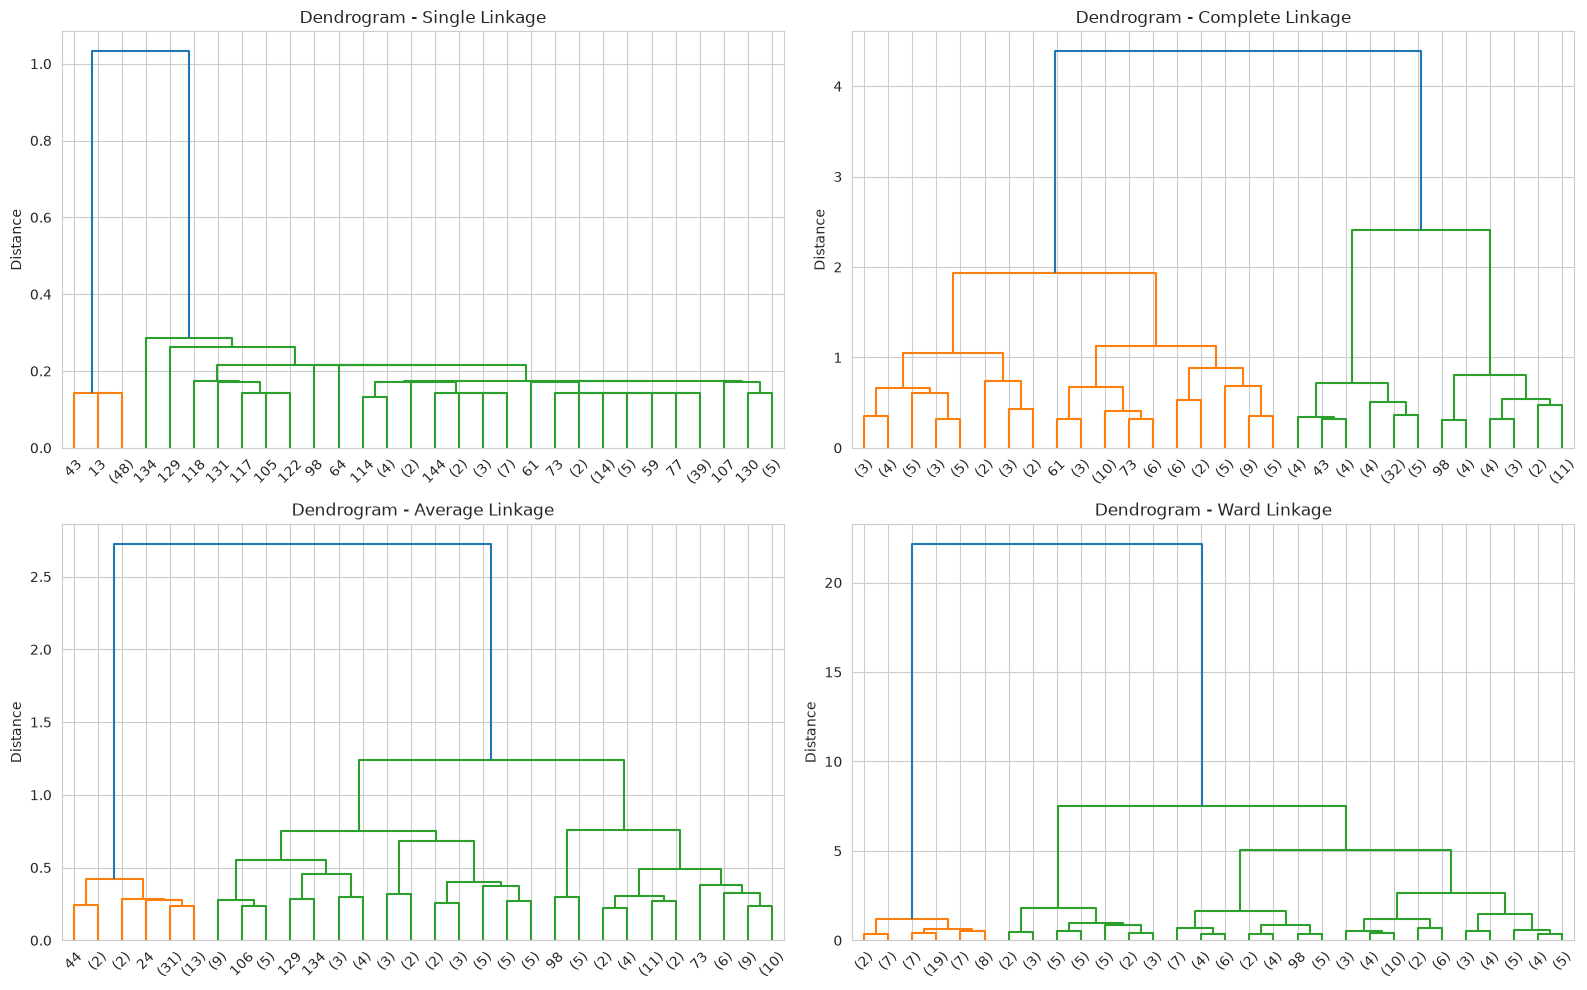

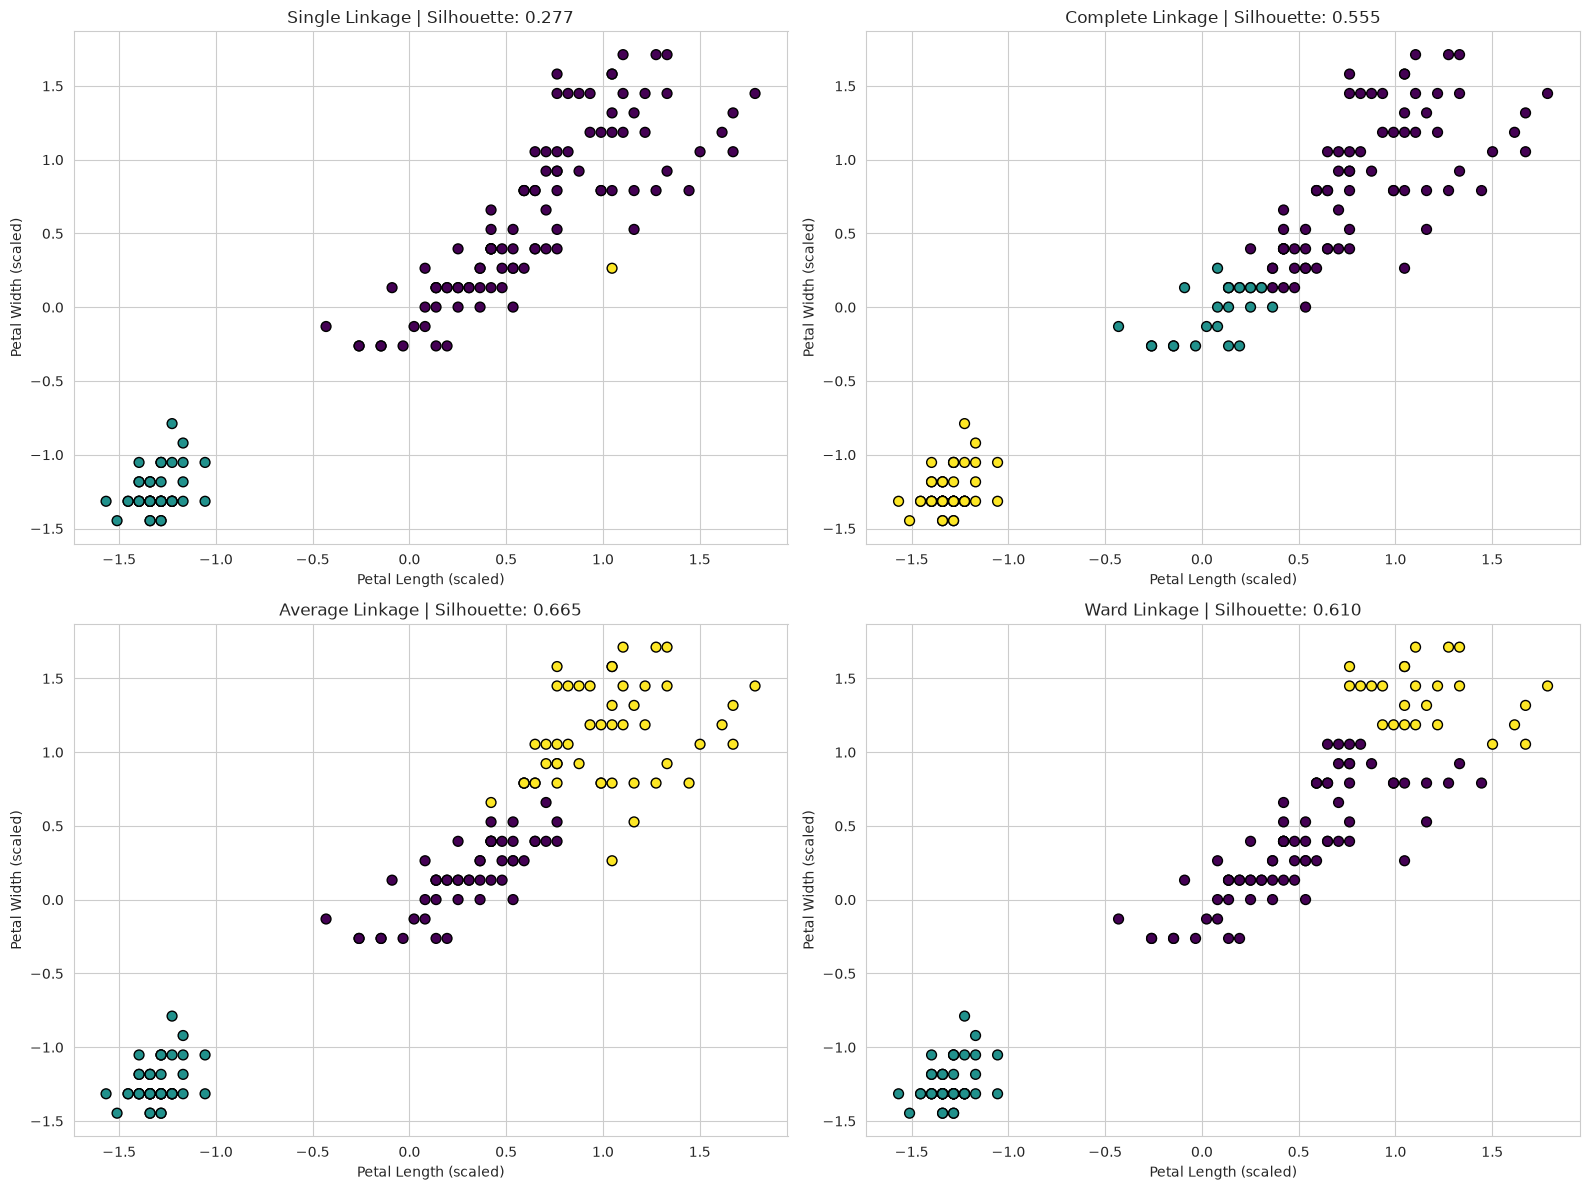

In [3]:
linkage_methods = ['single', 'complete', 'average', 'ward']
fig_dendro, axes_dendro = plt.subplots(2, 2, figsize=(16, 10))

# 1. Visualisasi Dendrogram untuk setiap Linkage
for idx, method in enumerate(linkage_methods):
    row, col = idx // 2, idx % 2
    Z = linkage(X_iris_scaled, method=method)
    dendrogram(Z, ax=axes_dendro[row, col], truncate_mode='lastp', p=30)
    axes_dendro[row, col].set_title(f'Dendrogram - {method.capitalize()} Linkage')
    axes_dendro[row, col].set_ylabel('Distance')

plt.tight_layout()
plt.show()

# 2. Perbandingan Clustering Agglomerative & Evaluasi Silhouette
fig_scatter, axes_scatter = plt.subplots(2, 2, figsize=(16, 12))

for idx, method in enumerate(linkage_methods):
    row, col = idx // 2, idx % 2
    agg = AgglomerativeClustering(n_clusters=3, linkage=method)
    labels_agg = agg.fit_predict(X_iris_scaled)
    
    score = silhouette_score(X_iris_scaled, labels_agg)
    
    axes_scatter[row, col].scatter(X_iris_scaled[:, 0], X_iris_scaled[:, 1], 
                                   c=labels_agg, cmap='viridis', edgecolors='k', s=50)
    axes_scatter[row, col].set_title(f'{method.capitalize()} Linkage | Silhouette: {score:.3f}')
    axes_scatter[row, col].set_xlabel('Petal Length (scaled)')
    axes_scatter[row, col].set_ylabel('Petal Width (scaled)')

plt.tight_layout()
plt.show()

### 📝 Interpretasi Tugas 2:
1. **Perbandingan Linkage:** 
   - **Single Linkage:** Sangat rentan terhadap noise/outlier, *cluster* berisiko mengalami *chaining effect* (menyatu panjang)[cite: 5].
   - **Ward Linkage:** Mengungguli metode lain karena meminimalkan varians di dalam kelompok (*within-cluster variance*), menghasilkan partisi *cluster* yang paling padat, proporsional, dan mirip dengan bentuk kelompok asli[cite: 5].
2. **Kesimpulan:** Metode **Ward** adalah pilihan terbaik karena mampu mendelineasi pemisahan antara Versicolor dan Virginica dengan *Silhouette Score* yang optimal dibandingkan tipe *linkage* lain.

---
## 📌 Tugas 3: K-Means vs Hierarchical Comparison (25 Poin)
Perbandingan kinerja model K-Means vs Hierarchical (Ward) meliputi *Silhouette Score*, *Davies-Bouldin Index*, dan waktu komputasi.

Task 3: K-Means vs Hierarchical

,Model,Silhouette Score,Davies-Bouldin Index,Computation Time (s)
0,K-Means,0.729106,0.379674,0.010019
1,Hierarchical (Ward),0.728800,0.379929,0.370866


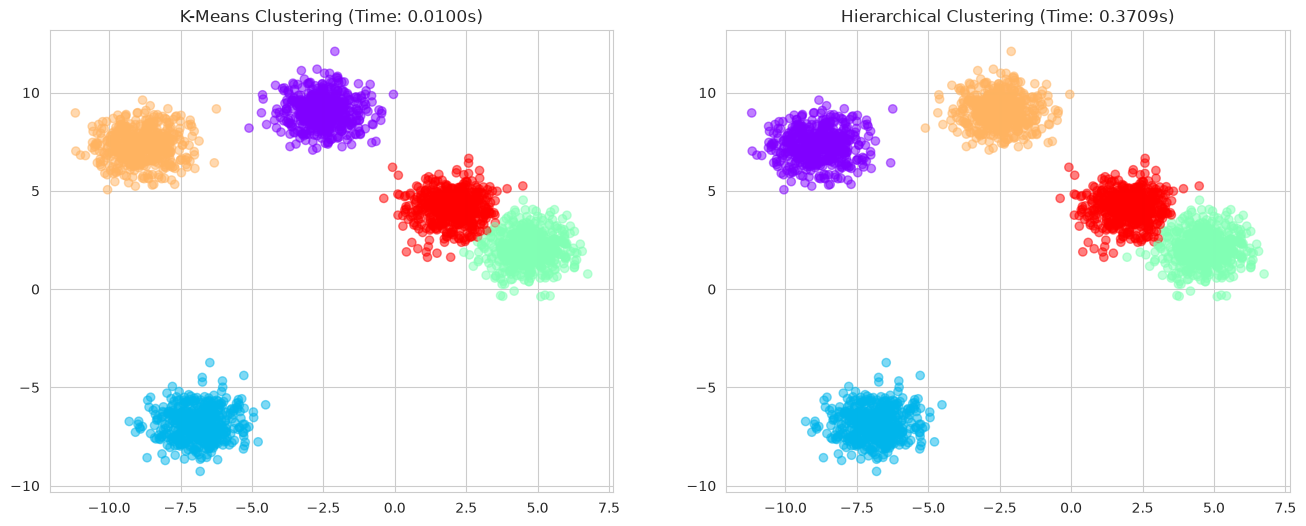

In [4]:
# 1. Generate Data Sintetis Besar
X_blobs, y_blobs = make_blobs(n_samples=2500, centers=5, n_features=2, cluster_std=0.8, random_state=42)

# 2. Eksekusi K-Means
start_time = time.time()
kmeans_model = KMeans(n_clusters=5, random_state=42)
labels_km = kmeans_model.fit_predict(X_blobs)
time_km = time.time() - start_time

# 3. Eksekusi Hierarchical Clustering (Ward)
start_time = time.time()
agg_model = AgglomerativeClustering(n_clusters=5, linkage='ward')
labels_agg = agg_model.fit_predict(X_blobs)
time_agg = time.time() - start_time

# 4. Evaluasi Metrics
res_comp = pd.DataFrame({
    'Model': ['K-Means', 'Hierarchical (Ward)'],
    'Silhouette Score': [silhouette_score(X_blobs, labels_km), silhouette_score(X_blobs, labels_agg)],
    'Davies-Bouldin Index': [davies_bouldin_score(X_blobs, labels_km), davies_bouldin_score(X_blobs, labels_agg)],
    'Computation Time (s)': [time_km, time_agg]
})

display(res_comp)

# 5. Visualisasi Perbandingan
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].scatter(X_blobs[:, 0], X_blobs[:, 1], c=labels_km, cmap='rainbow', alpha=0.5)
axes[0].set_title(f'K-Means Clustering (Time: {time_km:.4f}s)')

axes[1].scatter(X_blobs[:, 0], X_blobs[:, 1], c=labels_agg, cmap='rainbow', alpha=0.5)
axes[1].set_title(f'Hierarchical Clustering (Time: {time_agg:.4f}s)')

plt.show()

### 📝 Analisis Kelebihan & Kekurangan (Tugas 3):
1. **Performa Metrics:** Pada data yang memiliki batas *spherical* yang jelas (*blobs*), nilai evaluasi (Silhouette & Davies-Bouldin) antara K-Means dan Hierarchical hampir identik, membuktikan keduanya menangani bentuk geometris serupa dengan baik.
2. **Waktu Komputasi:** **K-Means jauh lebih cepat** ($O(N)$) dibandingkan Hierarchical Clustering ($O(N^3)$) pada dataset berskala di atas ratusan sampel[cite: 5].
3. **Aturan Penggunaan:**
   - Gunakan **K-Means** untuk dataset besar di mana kecepatan diekspektasikan dan kita sudah memiliki asumsi kuat terhadap jumlah K di awal[cite: 5].
   - Gunakan **Hierarchical** saat kita ingin memahami struktur taksonomi/hubungan hierarki dari dataset kecil tanpa perlu menentukan jumlah K terlebih dahulu secara tebakan[cite: 5].

---
## 📌 Tugas 4: Customer Segmentation Project (25 Poin)
Simulasi proyek bisnis melakukan *segmentasi pelanggan* berbasis dataset finansial *Age*, *Income*, dan *Spending Score*.

Task 4: Customer Segmentation

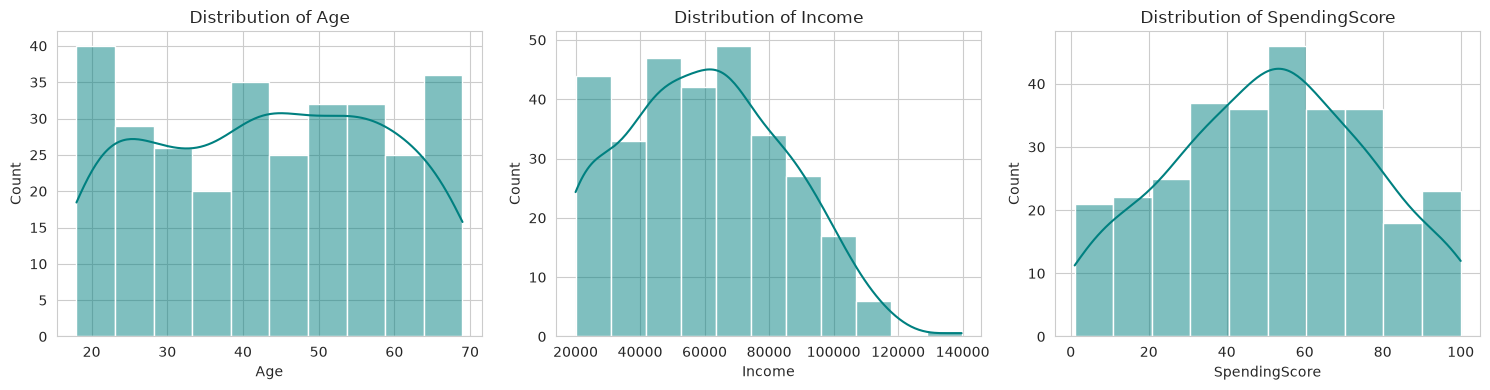

Optimal K for Customers: 4 (Based on Silhouette Peak)


,Age,Income,SpendingScore
Segment,,,
0,54.3,77188.6,30.9
1,56.2,39462.2,63.6
2,29.8,41751.5,38.0
3,34.2,78078.6,74.9


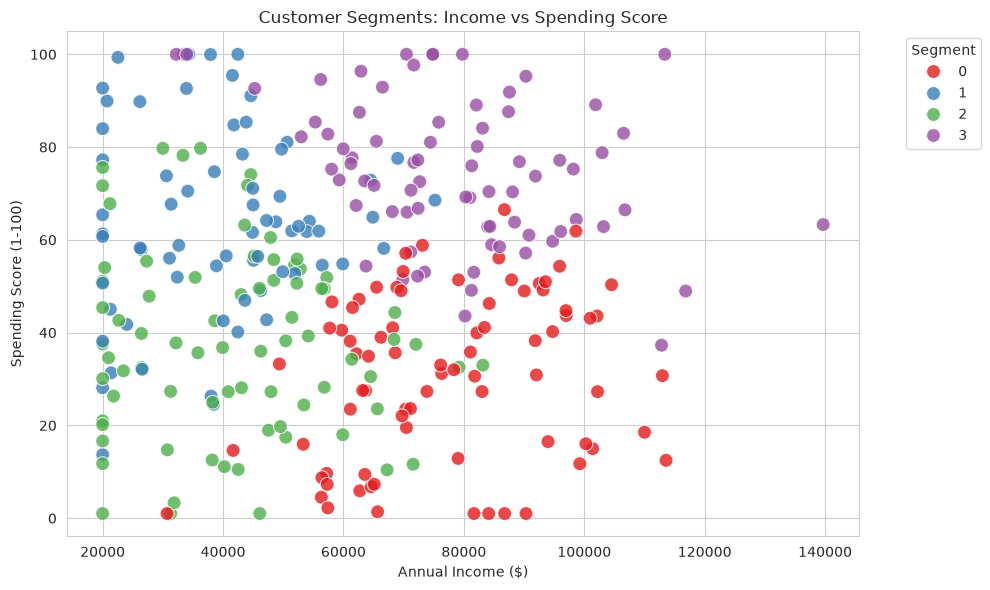

In [6]:
# 1. Generate Synthetic Customer Dataset (Mall Segmentation logic)
np.random.seed(42)
n_cust = 300
df_customer = pd.DataFrame({
    'Age': np.random.randint(18, 70, n_cust),
    'Income': np.random.normal(60000, 25000, n_cust).clip(20000, 150000),
    'SpendingScore': np.random.normal(50, 25, n_cust).clip(1, 100)
})

# 2. EDA: Distribusi Data
plt.figure(figsize=(15, 4))
for idx, col in enumerate(df_customer.columns):
    plt.subplot(1, 3, idx+1)
    sns.histplot(df_customer[col], kde=True, color='teal')
    plt.title(f'Distribution of {col}')
plt.tight_layout()
plt.show()

# 3. Preprocessing (Standardize Features Wajib)
scaler_cust = StandardScaler()
cust_scaled = scaler_cust.fit_transform(df_customer)

# 4. K Optimal Determination (Elbow & Silhouette)
k_c_range = range(2, 10)
inertias_c, sil_c = [], []

for k in k_c_range:
    km = KMeans(n_clusters=k, random_state=42)
    labels = km.fit_predict(cust_scaled)
    inertias_c.append(km.inertia_)
    sil_c.append(silhouette_score(cust_scaled, labels))

optimal_k_cust = k_c_range[np.argmax(sil_c)]
print(f"Optimal K for Customers: {optimal_k_cust} (Based on Silhouette Peak)")

# 5. Fit Final Model & Profiling
kmeans_final = KMeans(n_clusters=optimal_k_cust, random_state=42)
df_customer['Segment'] = kmeans_final.fit_predict(cust_scaled)

# Tampilkan Profiling
segment_profile = df_customer.groupby('Segment').mean().round(1)
display(segment_profile)

# 6. Visualisasi Segment (Income vs SpendingScore)
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_customer, x='Income', y='SpendingScore', hue='Segment', 
                palette='Set1', s=100, alpha=0.8)
plt.title('Customer Segments: Income vs Spending Score')
plt.xlabel('Annual Income ($)')
plt.ylabel('Spending Score (1-100)')
plt.legend(title='Segment', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

### 📝 Business Recommendations (Tugas 4):
*(Profil segmen dapat bervariasi bergantung nilai acak, namun ini adalah kerangka interpretasinya berdasarkan klaster `Income` vs `SpendingScore`)*

1. **Segment Target Utama (High Value):** Klaster pelanggan dengan pendapatan tinggi (Income > rata-rata) sekaligus skor pembelanjaan yang tinggi (Spending > rata-rata). 
   - *Marketing Strategy*: Program loyalitas eksklusif (VIP), penawaran produk premium yang dipersonalisasi. Ini adalah segmen paling bernilai untuk dijaga tingkat retensinya[cite: 5].
2. **Segment Potensial (High Income, Low Spending):** Pelanggan yang memiliki daya beli tinggi namun jarang berbelanja.
   - *Marketing Strategy*: Kirimkan survei untuk mengetahui kebutuhan mereka, atau berikan promosi diskon produk elektronik/kategori mahal untuk menstimulasi pengeluaran pertama mereka yang besar.
3. **Segment Hati-Hati (Low Income, High Spending):** Rentan finansial namun impulsif belanja.
   - *Marketing Strategy*: Tawarkan produk yang hemat, *bundling discount*, atau paket cicilan agar mereka tetap berbelanja tanpa merusak *credit risk*.